In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
# ── Cell 1 : imports + load data ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import xarray as xr
from scipy import ndimage
from scipy import stats
import subprocess
import glob, os, warnings
warnings.filterwarnings("ignore")

# install mann-kendall
subprocess.run(['pip', 'install', 'pymannkendall', '--quiet'], check=True)
import pymannkendall as mk

# install regionmask
subprocess.run(['pip', 'install', 'regionmask', '--quiet'], check=True)
import regionmask

print("imports done ✓")

# ── load ERA5 data ──
DATA_DIR = '/kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday'
nc_files  = sorted(glob.glob(f'{DATA_DIR}/**/*.nc', recursive=True))
print(f"found {len(nc_files)} files")

ds = xr.open_mfdataset(nc_files, combine='by_coords',
                        engine='h5netcdf', chunks=None)

data_precip = ds['tp'].values.astype('float32')
lat         = ds['latitude'].values.astype('float32')
lon         = ds['longitude'].values.astype('float32')
time        = ds['time'].values
times_pd    = pd.to_datetime(time)

print(f"shape : {data_precip.shape}")
print(f"time  : {str(times_pd[0])[:10]} → {str(times_pd[-1])[:10]}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 kB 3.2 MB/s eta 0:00:00
imports done ✓
found 46 files
shape : (5612, 141, 161)
time  : 1979-06-01 → 2024-09-30


In [8]:
# ── SETUP : load + mask + threshold + labeling (run this FIRST) ───────────────
import numpy as np, pandas as pd, xarray as xr, glob, subprocess, warnings
from scipy import ndimage
warnings.filterwarnings("ignore")

subprocess.run(['pip', 'install', 'regionmask', '--quiet'], check=True)
import regionmask

# --- load ERA5 ---
DATA_DIR = '/kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday'
nc_files = sorted(glob.glob(f'{DATA_DIR}/**/*.nc', recursive=True))
print(f"found {len(nc_files)} files")
ds = xr.open_mfdataset(nc_files, combine='by_coords', engine='h5netcdf', chunks=None)

data_precip = ds['tp'].values.astype('float32')
lat  = ds['latitude'].values.astype('float32')
lon  = ds['longitude'].values.astype('float32')
times_pd = pd.to_datetime(ds['time'].values)
print(f"shape : {data_precip.shape}   time : {str(times_pd[0])[:10]} -> {str(times_pd[-1])[:10]}")

# --- Section 1 : India mask + per-grid threshold ---
RAINY_DAY_MIN, PERCENTILE, FLOOR_MM = 1.0, 99.0, 50.0
countries  = regionmask.defined_regions.natural_earth_v5_0_0.countries_110
india_mask = (countries.mask(lon, lat).values == 98)
print(f"India cells : {india_mask.sum()} / {len(lat)*len(lon)}")

data_masked = np.where((data_precip > RAINY_DAY_MIN) & india_mask[np.newaxis, :, :],
                       data_precip, np.nan).astype('float32')
jjas_mask   = (times_pd.month >= 6) & (times_pd.month <= 9)
per_grid_99 = np.nanpercentile(data_masked[jjas_mask, :, :], PERCENTILE, axis=0).astype('float32')
per_grid_threshold = np.maximum(per_grid_99, FLOOR_MM).astype('float32')
per_grid_threshold[~india_mask] = 999.0

data_precip_safe = np.where(np.isnan(data_precip), 0.0, data_precip).astype('float32')
threshold_3d = np.broadcast_to(per_grid_threshold[np.newaxis, :, :], data_precip.shape).copy()
c = (data_precip_safe > threshold_3d)
print(f"exceedance rate : {c.mean()*100:.3f}%")

# --- Section 2 : 8-connectivity labeling ---
struct8 = ndimage.generate_binary_structure(2, 2)
n_days, n_lat, n_lon = data_precip.shape
Label8  = np.zeros((n_days, n_lat, n_lon), dtype='int32')
NE8_raw = np.zeros(n_days, dtype='int32')
for k in range(n_days):
    lab, nr = ndimage.label(c[k].astype('int8'), structure=struct8)
    Label8[k] = lab; NE8_raw[k] = nr
print(f"mean NE = {NE8_raw.mean():.3f} objects/day   labeling done ✓")

found 46 files
shape : (5612, 141, 161)   time : 1979-06-01 -> 2024-09-30
India cells : 4452 / 22701
exceedance rate : 0.114%
mean NE = 2.434 objects/day   labeling done ✓


In [9]:
stats_mean, summary_mean, merge_mean, split_mean = run_tracking_mean()

n_years = 2024 - 1979 + 1
print("MEAN tracker  (any-overlap continuation, no fallback)")
print(f"  total tracks         : {summary_mean.shape[0]:,}")
print(f"  total merges         : {len(merge_mean):,}")
print(f"  total splits         : {len(split_mean):,}")
print(f"  stat rows (obj-days) : {len(stats_mean):,}")
print(f"  avg tracks / season  : {summary_mean.shape[0]/n_years:.1f}   ({n_years} seasons)")

years = np.arange(1979, 2025)
tk   = summary_mean.groupby('year').size().reindex(years, fill_value=0)
mg   = (merge_mean.groupby('year').size().reindex(years, fill_value=0)
        if len(merge_mean) else pd.Series(0, index=years))
sp   = (split_mean.groupby('year').size().reindex(years, fill_value=0)
        if len(split_mean) else pd.Series(0, index=years))
maxd = summary_mean.groupby('year')['duration'].max().reindex(years, fill_value=0)
per_year = pd.DataFrame({'tracks': tk, 'merges': mg, 'splits': sp,
                         'events': mg + sp, 'max_dur': maxd})
print("\nper-year (1979–2024):")
print(per_year.to_string())

MEAN tracker  (any-overlap continuation, no fallback)
  total tracks         : 10,965
  total merges         : 173
  total splits         : 124
  stat rows (obj-days) : 13,659
  avg tracks / season  : 238.4   (46 seasons)

per-year (1979–2024):
      tracks  merges  splits  events  max_dur
year                                         
1979     202       2       5       7        4
1980     205       1       0       1        6
1981     147       1       3       4        3
1982     169       0       1       1        4
1983     243       6       2       8        5
1984     226       1       1       2        5
1985     223       0       1       1        4
1986     227       5       6      11        5
1987     197       4       4       8        5
1988     299       8       7      15        5
1989     245       4       3       7        5
1990     292       2       6       8        5
1991     241       7       0       7        6
1992     202       2       3       5        5
1993     223       

In [10]:
top3 = per_year.sort_values('events', ascending=False).head(3).index.tolist()
print("Top 3 years by structural events (merges + splits):", top3)
for y in top3:
    r = per_year.loc[y]
    print(f"  {y}: merges={int(r.merges)}  splits={int(r.splits)}  "
          f"tracks={int(r.tracks)}  longest track={int(r.max_dur)} days")

Top 3 years by structural events (merges + splits): [2007, 1988, 1995]
  2007: merges=11  splits=5  tracks=267  longest track=5 days
  1988: merges=8  splits=7  tracks=299  longest track=5 days
  1995: merges=11  splits=4  tracks=254  longest track=6 days


In [18]:
import matplotlib.pyplot as plt

# (track_num, 'YYYYMMDD') -> (lon, lat)
_pos = {(int(r.track_num), r.date): (r.centroid_lon, r.centroid_lat)
        for r in stats_mean.itertuples(index=False)}

def _prev(date_str):
    return (pd.to_datetime(str(date_str), format='%Y%m%d')
            - pd.Timedelta(days=1)).strftime('%Y%m%d')

def plot_year(year, n_longest=30, context=True):
    syr    = summary_mean[summary_mean['year'] == year]
    multid = syr[syr['duration'] > 1].sort_values('duration', ascending=False)
    focus  = set(multid.head(n_longest)['track_num'].tolist())
    singles = syr[syr['duration'] == 1]['track_num'].tolist()

    fig, ax = plt.subplots(figsize=(9, 10))
    LON, LAT = np.meshgrid(lon, lat)
    ax.contour(LON, LAT, india_mask.astype(int), levels=[0.5], colors='grey', linewidths=0.7)

    if context:                                   # faint context: other multiday tracks
        for tn in multid['track_num'].tolist():
            if tn in focus:
                continue
            g = stats_mean[stats_mean.track_num == tn].sort_values('day_of_track')
            ax.plot(g.centroid_lon, g.centroid_lat, '-', color='0.85', lw=0.6, zorder=1)

    for tn in focus:                              # focus tracks: black line + day points
        g = stats_mean[stats_mean.track_num == tn].sort_values('day_of_track')
        ax.plot(g.centroid_lon, g.centroid_lat, '-', color='black', lw=1.0, zorder=2)
        ax.scatter(g.centroid_lon, g.centroid_lat, s=12, color='black', zorder=3)
        ax.scatter(g.centroid_lon.iloc[0], g.centroid_lat.iloc[0], s=46,           # BIRTH
                   facecolors='none', edgecolors='black', lw=1.4, zorder=6)
        if g.iloc[-1]['end_type'] in ('natural_death', 'merge_death', 'domain_exit'):
            ax.scatter(g.centroid_lon.iloc[-1], g.centroid_lat.iloc[-1], s=46,     # DEATH
                       marker='x', color='black', lw=1.4, zorder=6)

    if singles:                                   # single-day tracks as dots
        sd = stats_mean[stats_mean.track_num.isin(singles)]
        ax.scatter(sd.centroid_lon, sd.centroid_lat, s=9, color='0.55', marker='.', zorder=2)

    if len(merge_mean):                           # RED merge: every parent_T -> child_T+1
        for r in merge_mean[merge_mean.year == year].itertuples(index=False):
            d0 = _prev(r.date); child = (r.centroid_lon, r.centroid_lat)
            parents = [int(r.dominant_track)] + [int(x) for x in
                       str(r.absorbed_tracks).split(',') if x.strip()]
            ax.scatter(*child, s=70, marker='o', facecolors='none',
                       edgecolors='red', lw=1.6, zorder=7)            # merge junction
            for p in parents:
                pt = _pos.get((p, d0))
                if pt:
                    ax.plot([pt[0], child[0]], [pt[1], child[1]], '-',
                            color='red', lw=1.8, zorder=5)
                    ax.scatter(*pt, s=18, color='red', zorder=7)       # parent endpoint

    if len(split_mean):                           # GREEN split: parent_T -> each daughter_T+1
        for r in split_mean[split_mean.year == year].itertuples(index=False):
            d1 = str(r.date); parent = (r.centroid_lon, r.centroid_lat)
            ax.scatter(*parent, s=70, marker='o', facecolors='none',
                       edgecolors='green', lw=1.6, zorder=7)          # split junction
            daughters = [int(x) for x in str(r.child_tracks).split(',') if x.strip()]
            # dominant daughter continues parent track -> its row on d1:
            dom = _pos.get((int(r.parent_track), d1))
            if dom:
                ax.plot([parent[0], dom[0]], [parent[1], dom[1]], '-',
                        color='green', lw=1.8, zorder=5)
                ax.scatter(*dom, s=18, color='green', zorder=7)
            for dt in daughters:
                pt = _pos.get((dt, d1))
                if pt:
                    ax.plot([parent[0], pt[0]], [parent[1], pt[1]], '-',
                            color='green', lw=1.8, zorder=5)
                    ax.scatter(*pt, s=18, color='green', zorder=7)    # daughter endpoint

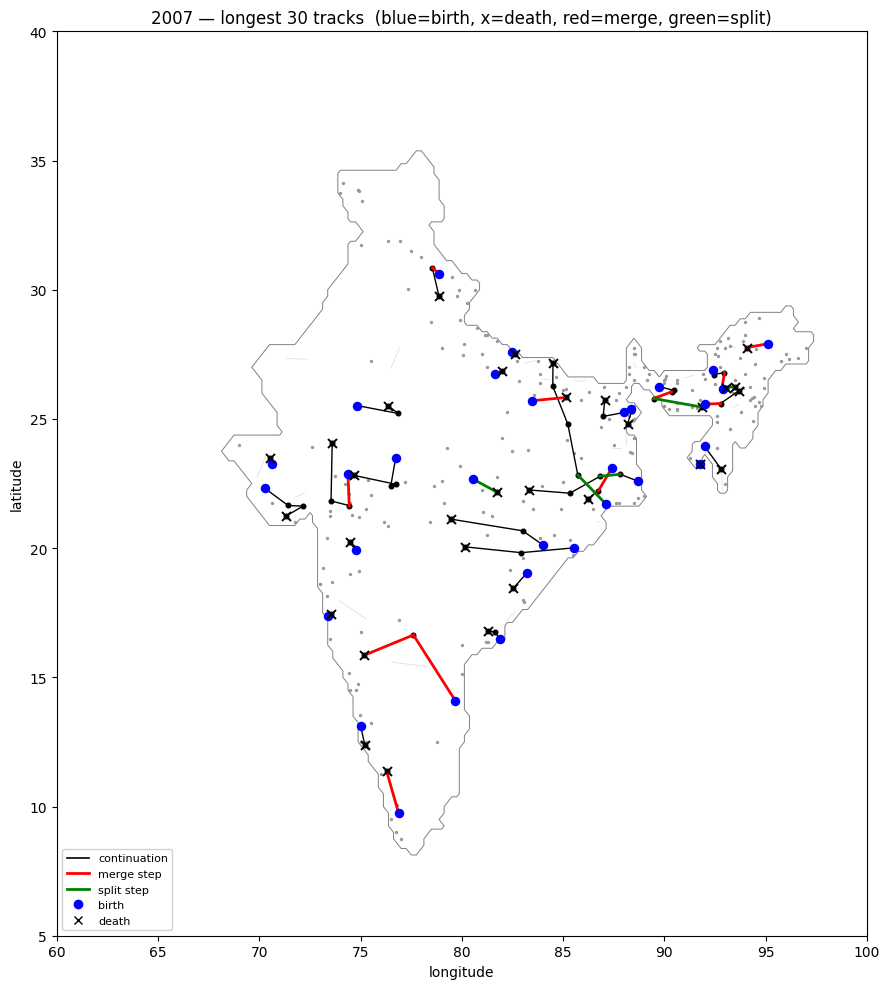

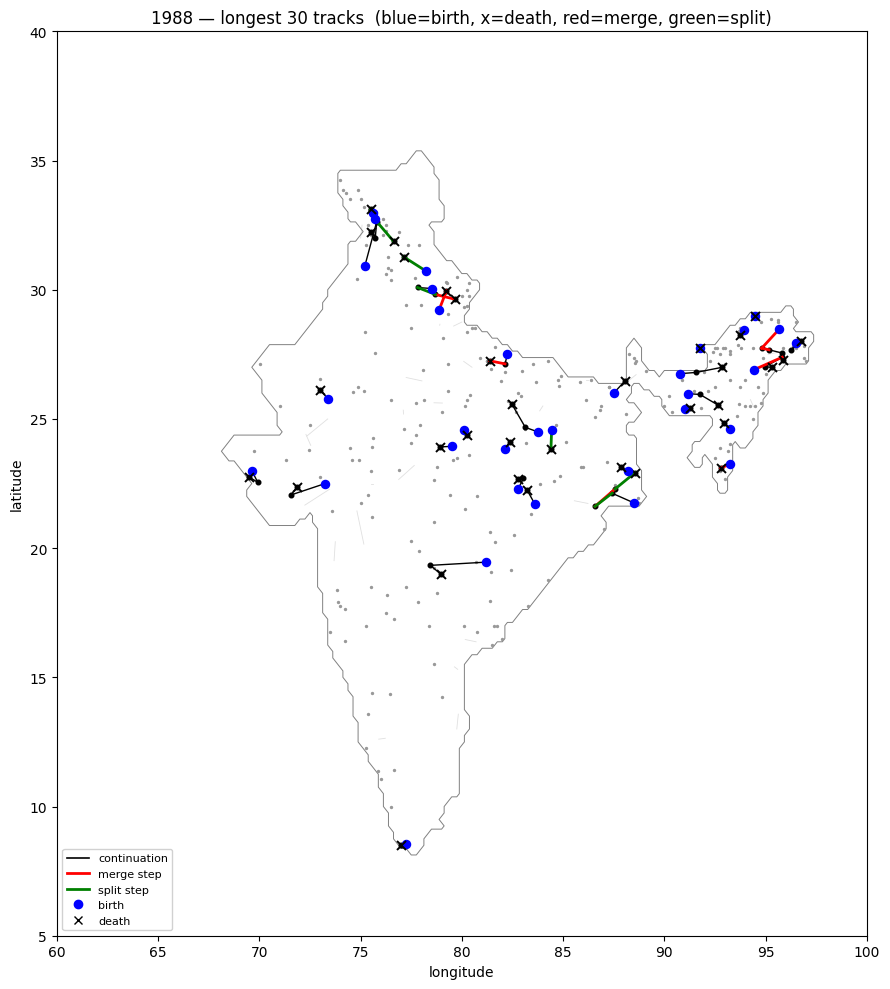

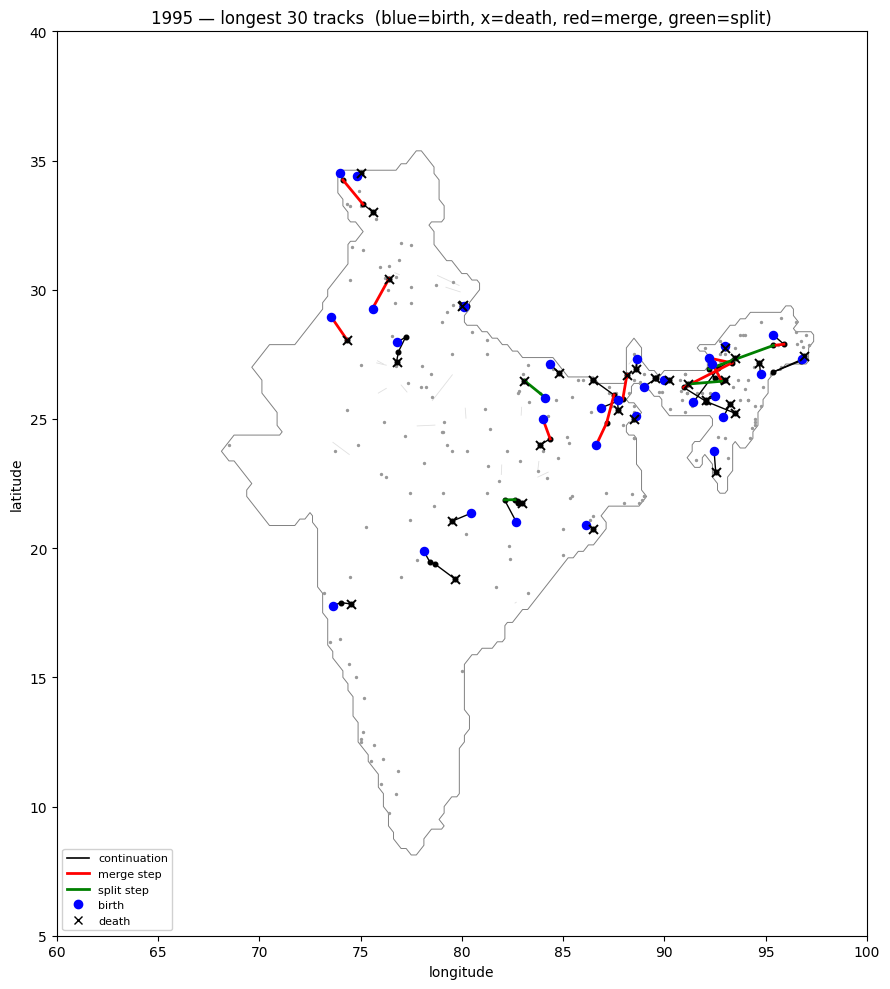

In [17]:
# ── Cell 4 (CLEAN) : lineage-coloured trajectory plot ────────────────────────
# black line = continuation       blue dot = birth        black x = death
# red line   = merge  : ONE segment, dominant parent(T) -> product(T+1)
# green line = split  : ONE segment, parent(T) -> dominant daughter(T+1)
# Only the single T->T+1 step is coloured; continuations revert to black.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# (track_num, 'YYYYMMDD') -> (lon, lat)
_pos = {(int(r.track_num), r.date): (r.centroid_lon, r.centroid_lat)
        for r in stats_mean.itertuples(index=False)}

def _prev(date_str):
    return (pd.to_datetime(str(date_str), format='%Y%m%d')
            - pd.Timedelta(days=1)).strftime('%Y%m%d')

def _colored_event_steps(year):
    """Return dict {(track_num, date_T1): colour} for the single T->T+1 step
    that should be drawn red (merge) or green (split). Used to skip those
    segments when drawing the black continuation line, so colour wins."""
    flagged = {}
    if len(merge_mean):
        for r in merge_mean[merge_mean.year == year].itertuples(index=False):
            flagged[(int(r.dominant_track), str(r.date))] = 'red'   # product day = T+1
    if len(split_mean):
        for r in split_mean[split_mean.year == year].itertuples(index=False):
            flagged[(int(r.parent_track), str(r.date))] = 'green'   # dominant daughter day = T+1
    return flagged

def plot_year(year, n_longest=30, context=True):
    syr    = summary_mean[summary_mean['year'] == year]
    multid = syr[syr['duration'] > 1].sort_values('duration', ascending=False)
    focus  = set(multid.head(n_longest)['track_num'].tolist())

    me = merge_mean[merge_mean.year == year] if len(merge_mean) else merge_mean.iloc[0:0]
    se = split_mean[split_mean.year == year] if len(split_mean) else split_mean.iloc[0:0]
    # ensure tracks involved in an event are drawn (dominant side only needed)
    for r in me.itertuples(index=False):
        focus.add(int(r.dominant_track))
    for r in se.itertuples(index=False):
        focus.add(int(r.parent_track))

    singles     = syr[(syr['duration'] == 1) & (~syr['track_num'].isin(focus))]['track_num'].tolist()
    context_tns = [tn for tn in multid['track_num'].tolist() if tn not in focus]
    flagged     = _colored_event_steps(year)

    fig, ax = plt.subplots(figsize=(9, 10))
    LON, LAT = np.meshgrid(lon, lat)
    ax.contour(LON, LAT, india_mask.astype(int), levels=[0.5], colors='grey', linewidths=0.7)

    # faint context: other multiday tracks
    if context:
        for tn in context_tns:
            g = stats_mean[stats_mean.track_num == tn].sort_values('day_of_track')
            ax.plot(g.centroid_lon, g.centroid_lat, '-', color='0.88', lw=0.6, zorder=1)

    # single-day tracks as small grey dots (birth shown separately in blue below)
    if singles:
        sd = stats_mean[stats_mean.track_num.isin(singles)]
        ax.scatter(sd.centroid_lon, sd.centroid_lat, s=8, color='0.6', marker='.', zorder=2)

    DEATHS = ('natural_death', 'merge_death', 'domain_exit')
    for tn in focus:
        g = stats_mean[stats_mean.track_num == tn].sort_values('day_of_track').reset_index(drop=True)
        if len(g) == 0:
            continue
        lons = g['centroid_lon'].values
        lats = g['centroid_lat'].values
        dates = g['date'].values
        # draw each black continuation segment, EXCEPT the one that is a coloured event step
        for i in range(1, len(g)):
            if flagged.get((tn, str(dates[i]))) is not None:
                continue   # this T->T+1 step is drawn red/green below, keep it black-free
            ax.plot([lons[i-1], lons[i]], [lats[i-1], lats[i]], '-',
                    color='black', lw=1.0, zorder=2)
        # day points
        ax.scatter(lons, lats, s=11, color='black', zorder=3)
        # BIRTH = blue dot at first centroid
        ax.scatter(lons[0], lats[0], s=34, color='blue', zorder=6)
        # DEATH = black x (real terminations only; season_end left unmarked)
        if g.iloc[-1]['end_type'] in DEATHS:
            ax.scatter(lons[-1], lats[-1], s=42, marker='x', color='black', lw=1.4, zorder=6)

    # RED merge: ONE segment dominant parent(T) -> product(T+1)
    for r in me.itertuples(index=False):
        d0    = _prev(r.date)
        child = _pos.get((int(r.dominant_track), str(r.date)))
        par   = _pos.get((int(r.dominant_track), d0))
        if child and par:
            ax.plot([par[0], child[0]], [par[1], child[1]], '-',
                    color='red', lw=2.0, zorder=5)

    # GREEN split: ONE segment parent(T) -> dominant daughter(T+1)
    for r in se.itertuples(index=False):
        d0     = _prev(r.date)
        parent = _pos.get((int(r.parent_track), d0))
        domd   = _pos.get((int(r.parent_track), str(r.date)))
        if parent and domd:
            ax.plot([parent[0], domd[0]], [parent[1], domd[1]], '-',
                    color='green', lw=2.0, zorder=5)

    legend = [
        Line2D([0], [0], color='black', lw=1.2, label='continuation'),
        Line2D([0], [0], color='red',   lw=2.0, label='merge step'),
        Line2D([0], [0], color='green', lw=2.0, label='split step'),
        Line2D([0], [0], marker='o', color='blue', lw=0, label='birth'),
        Line2D([0], [0], marker='x', color='black', lw=0, label='death'),
    ]
    ax.legend(handles=legend, loc='lower left', fontsize=8, framealpha=0.9)
    ax.set_title(f"{year} — longest {min(n_longest, len(multid))} tracks  "
                 f"(blue=birth, x=death, red=merge, green=split)")
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
    plt.tight_layout(); plt.show()

for y in top3:
    plot_year(y, n_longest=30, context=True)

In [21]:
# ── Cell 6 (COMPACT) : MEAN vs check_5_unified MAX / MIN ─────────────────────
import numpy as np, pandas as pd
n_years = 2024 - 1979 + 1

def core(df_sum, df_merge, df_split):
    t = df_sum.shape[0]
    return {'tracks': t,
            'merges': len(df_merge), 'splits': len(df_split),
            'tracks/yr': round(t / n_years, 1),
            'single-day %': round((df_sum['duration'] == 1).mean() * 100, 1),
            'max dur': int(df_sum['duration'].max())}

rows = {'MEAN (no fallback)': core(summary_mean, merge_mean, split_mean)}
if all(v in dir() for v in ['summary_max', 'merge_max', 'split_max',
                            'summary_min', 'merge_min', 'split_min']):
    rows['MAX (fallback)'] = core(summary_max, merge_max, split_max)
    rows['MIN (fallback)'] = core(summary_min, merge_min, split_min)
else:  # published check_5_unified values
    rows['MAX (fallback)'] = {'tracks':8856,'merges':179,'splits':132,
                              'tracks/yr':192.5,'single-day %':80.5,'max dur':np.nan}
    rows['MIN (fallback)'] = {'tracks':8841,'merges':39,'splits':29,
                              'tracks/yr':192.2,'single-day %':80.2,'max dur':np.nan}

print(pd.DataFrame(rows).T.to_string())
print(f"\nRemoving the centroid fallback: tracks {rows['MAX (fallback)']['tracks']} "
      f"-> {rows['MEAN (no fallback)']['tracks']} "
      f"(+{rows['MEAN (no fallback)']['tracks']-rows['MAX (fallback)']['tracks']}, "
      f"every distance-teleport became a death+birth). "
      f"Mean's {rows['MEAN (no fallback)']['merges']}/{rows['MEAN (no fallback)']['splits']} "
      f"merges/splits sit between MAX and MIN, as expected.")

                     tracks  merges  splits  tracks/yr  single-day %  max dur
MEAN (no fallback)  10965.0   173.0   124.0      238.4          82.2      9.0
MAX (fallback)       8856.0   179.0   132.0      192.5          80.5      NaN
MIN (fallback)       8841.0    39.0    29.0      192.2          80.2      NaN

Removing the centroid fallback: tracks 8856 -> 10965 (+2109, every distance-teleport became a death+birth). Mean's 173/124 merges/splits sit between MAX and MIN, as expected.


10 longest tracks across 1979–2024 (mean tracker):
rank   track  year  days  merges  splits   span
   1    3882  1996     9       0       0   19960620→19960628
   2    7392  2011     8       2       2   20110616→20110623
   3    3864  1996     7       1       1   19960613→19960619
   4    8778  2016     6       0       0   20160811→20160816
   5    4129  1997     6       0       0   19970708→19970713
   6    3841  1995     6       1       1   19950919→19950924
   7    8933  2017     6       1       0   20170721→20170726
   8    9987  2021     6       0       0   20210730→20210804
   9    9429  2019     6       1       0   20190803→20190808
  10    5259  2002     6       0       0   20020623→20020628

Years represented: [np.int64(1995), np.int64(1996), np.int64(1997), np.int64(2002), np.int64(2011), np.int64(2016), np.int64(2017), np.int64(2019), np.int64(2021)]
Duration range: 6–9 days


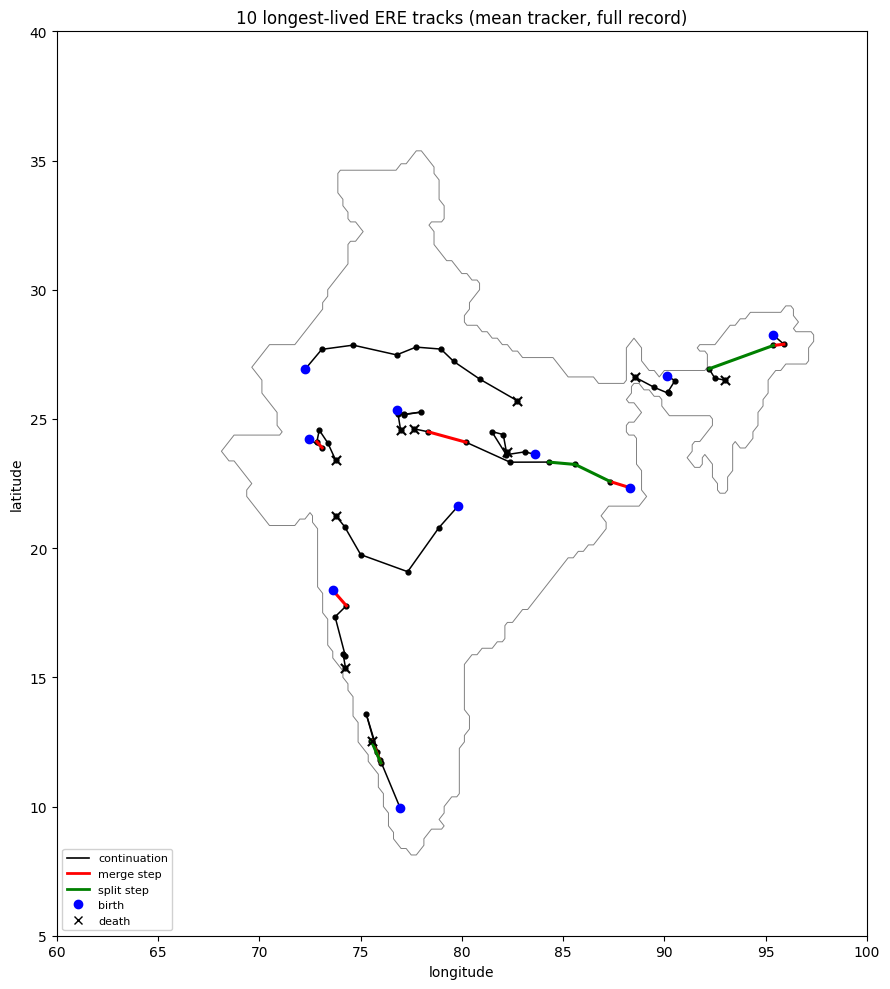

In [23]:
# ── Cell : 10 LONGEST tracks across all 46 years, minimal convention ─────────
# black = continuation   blue = birth   x = death
# red   = merge step (dominant parent T -> product T+1)
# green = split step (parent T -> dominant daughter T+1)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

_pos = {(int(r.track_num), r.date): (r.centroid_lon, r.centroid_lat)
        for r in stats_mean.itertuples(index=False)}
def _prev(d):
    return (pd.to_datetime(str(d), format='%Y%m%d') - pd.Timedelta(days=1)).strftime('%Y%m%d')

# --- pick the 10 longest-lived tracks over the whole record ---
top10 = summary_mean.sort_values('duration', ascending=False).head(10).copy()
top10_set = set(top10['track_num'].astype(int))

print("10 longest tracks across 1979–2024 (mean tracker):")
print(f"{'rank':>4} {'track':>7} {'year':>5} {'days':>5} {'merges':>7} {'splits':>7}   span")
for i, r in enumerate(top10.itertuples(index=False), 1):
    print(f"{i:>4} {int(r.track_num):>7} {int(r.year):>5} {int(r.duration):>5} "
          f"{int(r.n_merge_events):>7} {int(r.n_split_events):>7}   {r.birth_date}→{r.death_date}")
yrs = sorted(top10['year'].astype(int).unique())
print(f"\nYears represented: {yrs}")
print(f"Duration range: {int(top10['duration'].min())}–{int(top10['duration'].max())} days")

# --- coloured T->T+1 steps that belong to these 10 tracks ---
flagged = {}
if len(merge_mean):
    for r in merge_mean.itertuples(index=False):
        if int(r.dominant_track) in top10_set:
            flagged[(int(r.dominant_track), str(r.date))] = 'red'
if len(split_mean):
    for r in split_mean.itertuples(index=False):
        if int(r.parent_track) in top10_set:
            flagged[(int(r.parent_track), str(r.date))] = 'green'

# --- plot only the 10 tracks ---
fig, ax = plt.subplots(figsize=(9, 10))
LON, LAT = np.meshgrid(lon, lat)
ax.contour(LON, LAT, india_mask.astype(int), levels=[0.5], colors='grey', linewidths=0.7)

DEATHS = ('natural_death', 'merge_death', 'domain_exit')
for tn in top10_set:
    g = stats_mean[stats_mean.track_num == tn].sort_values('day_of_track').reset_index(drop=True)
    if len(g) == 0:
        continue
    lons, lats, dates = g['centroid_lon'].values, g['centroid_lat'].values, g['date'].values
    for k in range(1, len(g)):                              # black, skip coloured steps
        if flagged.get((tn, str(dates[k]))) is not None:
            continue
        ax.plot([lons[k-1], lons[k]], [lats[k-1], lats[k]], '-', color='black', lw=1.1, zorder=2)
    ax.scatter(lons, lats, s=12, color='black', zorder=3)
    ax.scatter(lons[0], lats[0], s=36, color='blue', zorder=6)          # BIRTH
    if g.iloc[-1]['end_type'] in DEATHS:                                 # DEATH
        ax.scatter(lons[-1], lats[-1], s=44, marker='x', color='black', lw=1.5, zorder=6)

# RED merge steps (dominant parent -> product)
if len(merge_mean):
    for r in merge_mean.itertuples(index=False):
        if int(r.dominant_track) not in top10_set:
            continue
        par   = _pos.get((int(r.dominant_track), _prev(r.date)))
        child = _pos.get((int(r.dominant_track), str(r.date)))
        if par and child:
            ax.plot([par[0], child[0]], [par[1], child[1]], '-', color='red', lw=2.2, zorder=5)

# GREEN split steps (parent -> dominant daughter)
if len(split_mean):
    for r in split_mean.itertuples(index=False):
        if int(r.parent_track) not in top10_set:
            continue
        parent = _pos.get((int(r.parent_track), _prev(r.date)))
        domd   = _pos.get((int(r.parent_track), str(r.date)))
        if parent and domd:
            ax.plot([parent[0], domd[0]], [parent[1], domd[1]], '-', color='green', lw=2.2, zorder=5)

ax.legend(handles=[
    Line2D([0],[0], color='black', lw=1.2, label='continuation'),
    Line2D([0],[0], color='red',   lw=2.0, label='merge step'),
    Line2D([0],[0], color='green', lw=2.0, label='split step'),
    Line2D([0],[0], marker='o', color='blue',  lw=0, label='birth'),
    Line2D([0],[0], marker='x', color='black', lw=0, label='death'),
], loc='lower left', fontsize=8, framealpha=0.9)
ax.set_title("10 longest-lived ERE tracks (mean tracker, full record)")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
plt.tight_layout(); plt.show()

MEAN + 2° fallback : tracks=8,835  merges=173  splits=124

multiday tracks only        no-fallback     +2° fallback
  count                          1952            3115
  median duration (days)          2.0             2.0
  median net displ. (km)         61.0           106.8
  median path length (km)        66.3           123.8
  max net displ. (km)          1114.8          1235.3


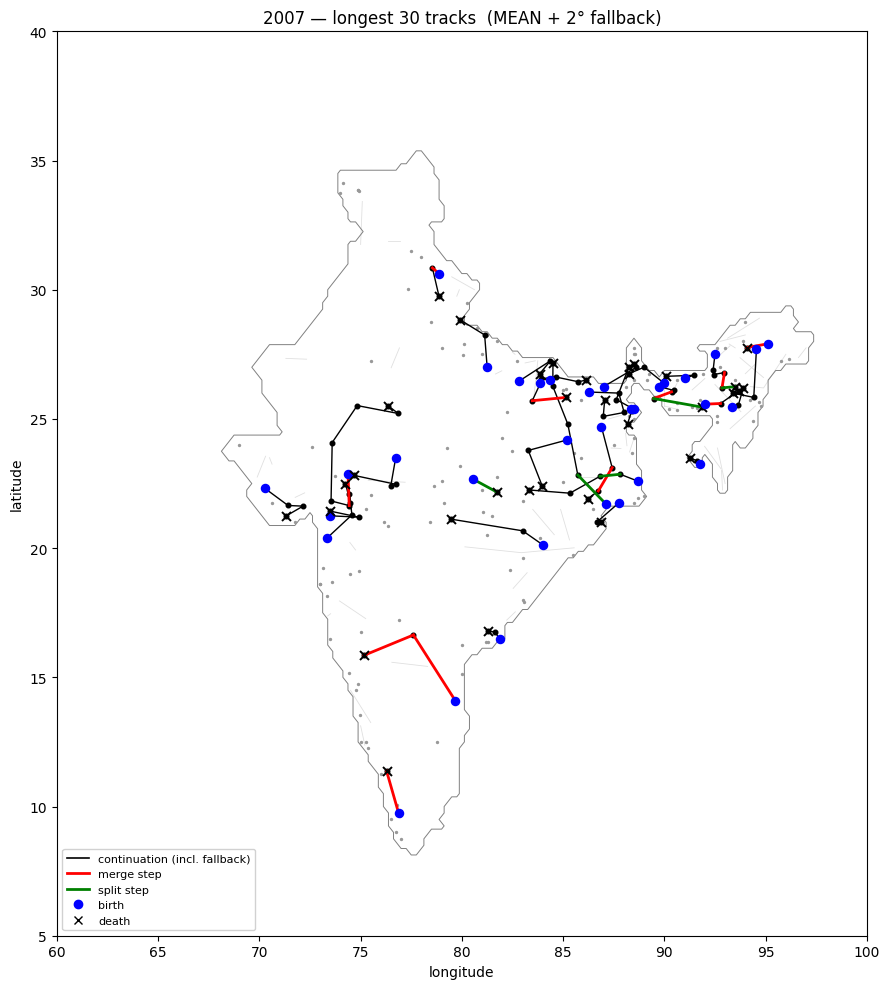

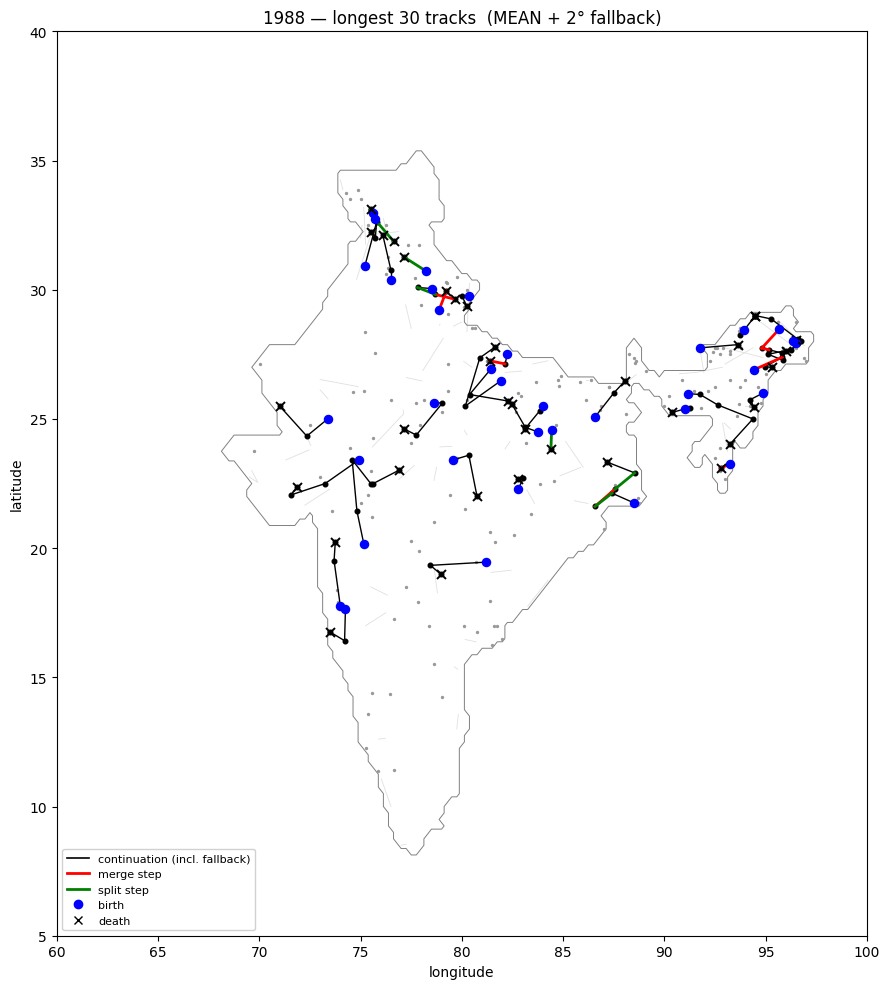

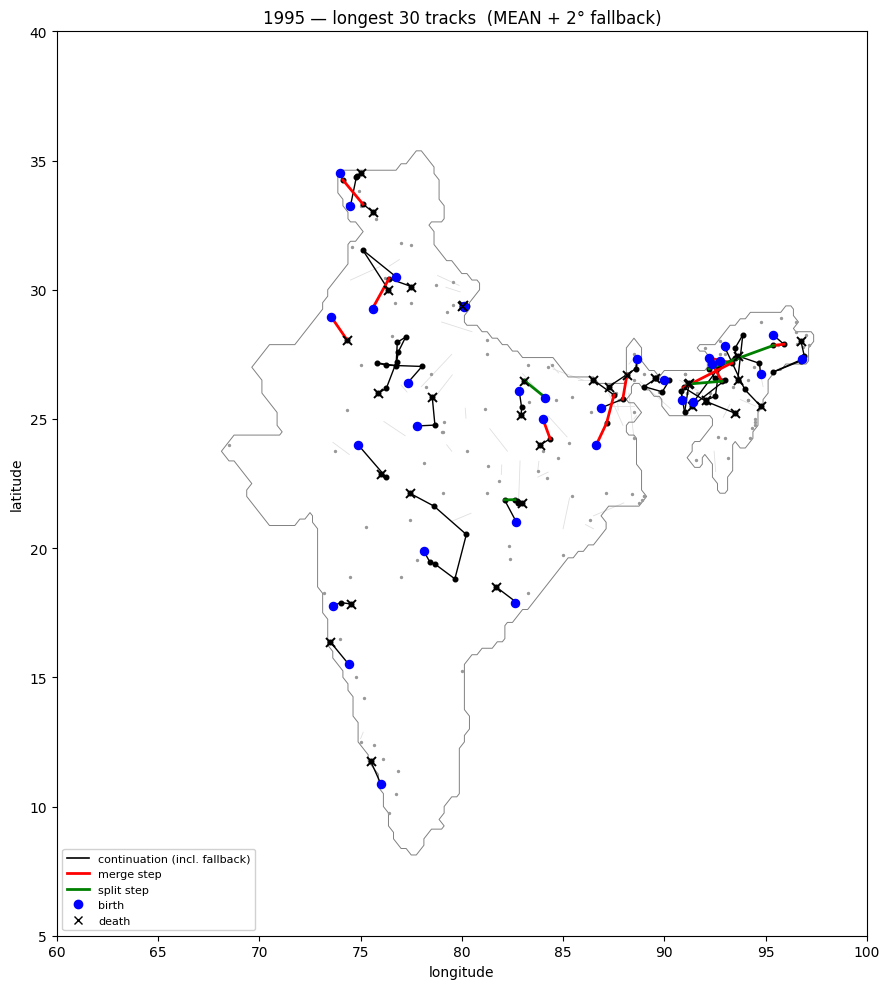

In [25]:
# ── Cell : MEAN tracker WITH 2° centroid fallback  +  top-3 plots ────────────
# Identical to the mean tracker, except Step 4 is the distance fallback again:
# an active track with ZERO overlap next day links to the nearest centroid
# within SEARCH_DEG (2.0°); only if none is found does it die.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

OVERLAP_THRESH, MIN_TRACK_CELLS, DOMAIN_EXIT_FRAC, SEARCH_DEG = 0.10, 1, 0.50, 2.0

def run_tracking_mean_fb():
    track_stats_rows, merge_event_rows, split_event_rows = [], [], []
    active_tracks, births_per_date = {}, {}
    counters = {'track': 0, 'merge': 0, 'split': 0}

    def jjas_day_num(ts): return int((ts - pd.Timestamp(f"{ts.year}-06-01")).days + 1)

    def get_objects(day_idx):
        labeled, n_obj, objs = Label8[day_idx], NE8_raw[day_idx], {}
        for lbl in range(1, n_obj + 1):
            mask = (labeled == lbl); sz = int(mask.sum())
            if sz < MIN_TRACK_CELLS: continue
            r_, c_ = np.where(mask)
            objs[lbl] = {'size': sz,
                         'centroid': (float(lat[r_].mean()), float(lon[c_].mean())),
                         'outside': int((mask & ~india_mask).sum())}
        return objs

    def compute_overlaps(dt, dt1, ot, ot1):
        lab_t, lab_t1, pairs = Label8[dt], Label8[dt1], {}
        for li in ot:
            mi = (lab_t == li)
            for lj in np.unique(lab_t1[mi]):
                if lj == 0 or lj not in ot1: continue
                sh = int((mi & (lab_t1 == lj)).sum())
                if sh == 0: continue
                fwd, bwd = sh / ot[li]['size'], sh / ot1[lj]['size']
                pairs[(li, lj)] = (fwd, bwd, sh, (fwd + bwd) / 2.0)   # MEAN
        return pairs

    def domain_exit(o): return (o['outside'] / o['size']) > DOMAIN_EXIT_FRAC

    def new_track(di, lbl, o, start_type, split_from=-1):
        counters['track'] += 1; tnum, ts = counters['track'], times_pd[di]
        ds = ts.strftime('%Y%m%d')
        births_per_date[ds] = births_per_date.get(ds, 0) + 1
        tid = f"{ds}_{births_per_date[ds]:03d}"; clat, clon = o['centroid']
        row = {'track_num': tnum, 'track_id': tid, 'date': ds, 'year': ts.year,
               'jjas_day': jjas_day_num(ts), 'day_of_track': 0, 'size': o['size'],
               'centroid_lat': round(clat, 3), 'centroid_lon': round(clon, 3),
               'merge_event': False, 'split_event': False, 'link_type': 'birth',
               'start_type': start_type, 'end_type': None, 'duration': None,
               'split_from_track': split_from, 'merge_into_track': -1, 'day_lbl': lbl}
        active_tracks[tnum] = {'track_id': tid, 'last_day': di, 'last_lbl': lbl,
                               'last_centroid': o['centroid'], 'last_size': o['size'],
                               'start_type': start_type, 'duration': 1,
                               'split_from': split_from, 'daily_rows': [row]}
        return tnum

    def extend_track(tnum, di, lbl, o, merge_event=False, split_event=False, link_type='overlap'):
        tr = active_tracks[tnum]; tr['duration'] += 1; ts = times_pd[di]; clat, clon = o['centroid']
        tr['daily_rows'].append(
            {'track_num': tnum, 'track_id': tr['track_id'], 'date': ts.strftime('%Y%m%d'),
             'year': ts.year, 'jjas_day': jjas_day_num(ts), 'day_of_track': tr['duration'] - 1,
             'size': o['size'], 'centroid_lat': round(clat, 3), 'centroid_lon': round(clon, 3),
             'merge_event': merge_event, 'split_event': split_event, 'link_type': link_type,
             'start_type': tr['start_type'], 'end_type': None, 'duration': None,
             'split_from_track': tr['split_from'], 'merge_into_track': -1, 'day_lbl': lbl})
        tr['last_day'], tr['last_lbl'] = di, lbl
        tr['last_centroid'], tr['last_size'] = o['centroid'], o['size']

    def terminate_track(tnum, end_type, merge_into=-1):
        tr = active_tracks[tnum]; dur = tr['duration']; rows = tr['daily_rows']
        for r in rows: r['duration'] = dur
        rows[-1]['end_type'] = end_type; rows[-1]['merge_into_track'] = merge_into
        track_stats_rows.extend(rows); del active_tracks[tnum]

    for lbl, o in get_objects(0).items():
        tn = new_track(0, lbl, o, 'season_start')
        if domain_exit(o): terminate_track(tn, 'domain_exit')

    for di in range(n_days - 1):
        ts_today, ts_next = times_pd[di], times_pd[di + 1]
        if ts_today.month == 9 and ts_today.day == 30:
            for tn in list(active_tracks): terminate_track(tn, 'season_end')
            for lbl, o in get_objects(di + 1).items():
                tn = new_track(di + 1, lbl, o, 'season_start')
                if domain_exit(o): terminate_track(tn, 'domain_exit')
            continue
        ot, ot1 = get_objects(di), get_objects(di + 1)
        if len(ot1) == 0:
            for tn in list(active_tracks): terminate_track(tn, 'natural_death')
            continue
        if len(ot) == 0:
            for tn in list(active_tracks): terminate_track(tn, 'natural_death')
            for lbl, o in ot1.items():
                tn = new_track(di + 1, lbl, o, 'natural_birth')
                if domain_exit(o): terminate_track(tn, 'domain_exit')
            continue

        pairs = compute_overlaps(di, di + 1, ot, ot1)
        fwd_links, bwd_links = {}, {}
        for (li, lj), (f, b, sh, sc) in pairs.items():
            fwd_links.setdefault(li, []).append((lj, f, b, sh, sc))
            bwd_links.setdefault(lj, []).append((li, f, b, sh, sc))
        lbl_to_track = {tr['last_lbl']: tn for tn, tr in active_tracks.items() if tr['last_day'] == di}
        handled_today, handled_next = set(), set()

        # STEP 1 : MERGES
        mc = []
        for lj in ot1:
            par = [(li, f, b, sh, sc) for (li, f, b, sh, sc) in bwd_links.get(lj, [])
                   if sc >= OVERLAP_THRESH and li in lbl_to_track]
            if len(par) >= 2: mc.append((sum(p[4] for p in par), lj, par))
        mc.sort(key=lambda x: x[0], reverse=True)
        for combined, lj, par in mc:
            if lj in handled_next or any(p[0] in handled_today for p in par): continue
            par = [p for p in par if lbl_to_track.get(p[0]) in active_tracks]
            if len(par) < 2: continue
            par.sort(key=lambda p: ot[p[0]]['size'], reverse=True)
            obj_j = ot1[lj]; dom_li = par[0][0]; dom_tn = lbl_to_track[dom_li]
            absorbed = par[1:]; absorbed_tns = [lbl_to_track[p[0]] for p in absorbed]
            clat_j, clon_j = obj_j['centroid']; counters['merge'] += 1
            merge_event_rows.append(
                {'merge_id': counters['merge'], 'date': ts_next.strftime('%Y%m%d'),
                 'year': ts_next.year, 'jjas_day': jjas_day_num(ts_next), 'dominant_track': dom_tn,
                 'absorbed_tracks': ','.join(str(t) for t in absorbed_tns),
                 'n_absorbed': len(absorbed_tns), 'merged_size_after': obj_j['size'],
                 'centroid_lat': round(clat_j, 3), 'centroid_lon': round(clon_j, 3)})
            extend_track(dom_tn, di + 1, lj, obj_j, merge_event=True, link_type='merge')
            for atn in absorbed_tns: terminate_track(atn, 'merge_death', merge_into=dom_tn)
            for p in par: handled_today.add(p[0])
            handled_next.add(lj)

        # STEP 2 : SPLITS
        for li, obj_i in ot.items():
            if li in handled_today or li not in lbl_to_track: continue
            par_tn = lbl_to_track[li]
            if par_tn not in active_tracks: continue
            ch = [(lj, f, b, sh, sc) for (lj, f, b, sh, sc) in fwd_links.get(li, [])
                  if sc >= OVERLAP_THRESH and lj not in handled_next]
            if len(ch) < 2: continue
            ch.sort(key=lambda c: ot1[c[0]]['size'], reverse=True)
            dom_lj = ch[0][0]; dom_obj = ot1[dom_lj]; others = ch[1:]
            clat_i, clon_i = obj_i['centroid']
            extend_track(par_tn, di + 1, dom_lj, dom_obj, split_event=True, link_type='split')
            handled_today.add(li); handled_next.add(dom_lj); child_tns = []
            for c in others:
                ctn = new_track(di + 1, c[0], ot1[c[0]], 'split_birth', split_from=par_tn)
                handled_next.add(c[0]); child_tns.append(ctn)
                if domain_exit(ot1[c[0]]): terminate_track(ctn, 'domain_exit')
            counters['split'] += 1
            split_event_rows.append(
                {'split_id': counters['split'], 'date': ts_next.strftime('%Y%m%d'),
                 'year': ts_next.year, 'jjas_day': jjas_day_num(ts_next),
                 'parent_track': par_tn, 'child_tracks': ','.join(str(t) for t in child_tns),
                 'n_children': len(child_tns), 'parent_size': obj_i['size'],
                 'centroid_lat': round(clat_i, 3), 'centroid_lon': round(clon_i, 3)})

        # STEP 3 : CONTINUATIONS — any non-zero overlap, strongest shared wins
        cc = [(sh, li, lj) for (li, lj), (f, b, sh, sc) in pairs.items()
              if li not in handled_today and lj not in handled_next and li in lbl_to_track]
        cc.sort(key=lambda x: x[0], reverse=True)
        for sh, li, lj in cc:
            if li in handled_today or lj in handled_next: continue
            tn = lbl_to_track.get(li)
            if tn is None or tn not in active_tracks: continue
            obj_j = ot1[lj]
            extend_track(tn, di + 1, lj, obj_j, link_type='overlap')
            handled_today.add(li); handled_next.add(lj)
            if domain_exit(obj_j): terminate_track(tn, 'domain_exit')

        # STEP 4 : FALLBACK — nearest centroid within SEARCH_DEG, else die
        for tn in list(active_tracks.keys()):
            tr = active_tracks.get(tn)
            if tr is None or tr['last_day'] != di: continue
            clat_i, clon_i = tr['last_centroid']; best_lj, best_d = None, float('inf')
            for lj, obj_j in ot1.items():
                if lj in handled_next: continue
                clat_j, clon_j = obj_j['centroid']
                d = ((clat_j - clat_i) ** 2 + (clon_j - clon_i) ** 2) ** 0.5
                if d <= SEARCH_DEG and d < best_d: best_d, best_lj = d, lj
            if best_lj is not None:
                obj_j = ot1[best_lj]
                extend_track(tn, di + 1, best_lj, obj_j, link_type='fallback')
                handled_next.add(best_lj)
                if domain_exit(obj_j): terminate_track(tn, 'domain_exit')
            else:
                terminate_track(tn, 'natural_death')

        # STEP 5 : BIRTHS
        for lj, obj_j in ot1.items():
            if lj in handled_next: continue
            tn = new_track(di + 1, lj, obj_j, 'natural_birth')
            if domain_exit(obj_j): terminate_track(tn, 'domain_exit')

    for tn in list(active_tracks): terminate_track(tn, 'season_end')

    df_stats = pd.DataFrame(track_stats_rows)
    df_merge = pd.DataFrame(merge_event_rows) if merge_event_rows else pd.DataFrame()
    df_split = pd.DataFrame(split_event_rows) if split_event_rows else pd.DataFrame()
    srows = []
    for tnum, grp in df_stats.groupby('track_num'):
        first, last = grp.iloc[0], grp.iloc[-1]
        srows.append({'track_num': tnum, 'track_id': first['track_id'],
                      'birth_date': first['date'], 'death_date': last['date'],
                      'year': int(first['year']),
                      'duration': int(first['duration']) if pd.notna(first['duration']) else len(grp),
                      'peak_size': int(grp['size'].max()),
                      'start_type': first['start_type'], 'end_type': last['end_type'],
                      'n_merge_events': int(grp['merge_event'].sum()),
                      'n_split_events': int(grp['split_event'].sum())})
    return df_stats, pd.DataFrame(srows), df_merge, df_split

stats_fb, summary_fb, merge_fb, split_fb = run_tracking_mean_fb()
print(f"MEAN + 2° fallback : tracks={summary_fb.shape[0]:,}  "
      f"merges={len(merge_fb)}  splits={len(split_fb)}")

# ── distance comparison : no-fallback (stats_mean) vs fallback (stats_fb) ─────
def hav(la1, lo1, la2, lo2):
    R = 6371.0; p1, p2 = np.radians(la1), np.radians(la2)
    dphi, dlmb = np.radians(la2 - la1), np.radians(lo2 - lo1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlmb/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

def track_distances(df_stats):
    rows = []
    for tn, g in df_stats.sort_values(['track_num', 'day_of_track']).groupby('track_num'):
        if len(g) < 2: continue
        la = g['centroid_lat'].values; lo = g['centroid_lon'].values
        steps = hav(la[:-1], lo[:-1], la[1:], lo[1:])
        rows.append({'dur': len(g), 'net_km': hav(la[0], lo[0], la[-1], lo[-1]),
                     'path_km': float(np.nansum(steps))})
    return pd.DataFrame(rows)

dn = track_distances(stats_mean)   # no fallback
df_ = track_distances(stats_fb)    # with fallback
print("\nmultiday tracks only        no-fallback     +2° fallback")
print(f"  count                    {len(dn):>10}{len(df_):>16}")
print(f"  median duration (days)   {dn.dur.median():>10.1f}{df_.dur.median():>16.1f}")
print(f"  median net displ. (km)   {dn.net_km.median():>10.1f}{df_.net_km.median():>16.1f}")
print(f"  median path length (km)  {dn.path_km.median():>10.1f}{df_.path_km.median():>16.1f}")
print(f"  max net displ. (km)      {dn.net_km.max():>10.1f}{df_.net_km.max():>16.1f}")

# ── plot the same top-3 years, minimal convention, using the fallback run ────
_posfb = {(int(r.track_num), r.date): (r.centroid_lon, r.centroid_lat)
          for r in stats_fb.itertuples(index=False)}
def _prev(d): return (pd.to_datetime(str(d), format='%Y%m%d') - pd.Timedelta(days=1)).strftime('%Y%m%d')

def plot_year_fb(year, n_longest=30, context=True):
    syr = summary_fb[summary_fb['year'] == year]
    multid = syr[syr['duration'] > 1].sort_values('duration', ascending=False)
    focus = set(multid.head(n_longest)['track_num'].tolist())
    me = merge_fb[merge_fb.year == year] if len(merge_fb) else merge_fb.iloc[0:0]
    se = split_fb[split_fb.year == year] if len(split_fb) else split_fb.iloc[0:0]
    for r in me.itertuples(index=False): focus.add(int(r.dominant_track))
    for r in se.itertuples(index=False): focus.add(int(r.parent_track))
    flagged = {}
    for r in me.itertuples(index=False): flagged[(int(r.dominant_track), str(r.date))] = 'red'
    for r in se.itertuples(index=False): flagged[(int(r.parent_track),  str(r.date))] = 'green'
    singles = syr[(syr['duration'] == 1) & (~syr['track_num'].isin(focus))]['track_num'].tolist()
    context_tns = [tn for tn in multid['track_num'].tolist() if tn not in focus]

    fig, ax = plt.subplots(figsize=(9, 10))
    LON, LAT = np.meshgrid(lon, lat)
    ax.contour(LON, LAT, india_mask.astype(int), levels=[0.5], colors='grey', linewidths=0.7)
    if context:
        for tn in context_tns:
            g = stats_fb[stats_fb.track_num == tn].sort_values('day_of_track')
            ax.plot(g.centroid_lon, g.centroid_lat, '-', color='0.88', lw=0.6, zorder=1)
    if singles:
        sd = stats_fb[stats_fb.track_num.isin(singles)]
        ax.scatter(sd.centroid_lon, sd.centroid_lat, s=8, color='0.6', marker='.', zorder=2)
    DEATHS = ('natural_death', 'merge_death', 'domain_exit')
    for tn in focus:
        g = stats_fb[stats_fb.track_num == tn].sort_values('day_of_track').reset_index(drop=True)
        if len(g) == 0: continue
        lons, lats, dates = g['centroid_lon'].values, g['centroid_lat'].values, g['date'].values
        for i in range(1, len(g)):
            if flagged.get((tn, str(dates[i]))) is not None: continue
            ax.plot([lons[i-1], lons[i]], [lats[i-1], lats[i]], '-', color='black', lw=1.0, zorder=2)
        ax.scatter(lons, lats, s=11, color='black', zorder=3)
        ax.scatter(lons[0], lats[0], s=34, color='blue', zorder=6)
        if g.iloc[-1]['end_type'] in DEATHS:
            ax.scatter(lons[-1], lats[-1], s=42, marker='x', color='black', lw=1.4, zorder=6)
    for r in me.itertuples(index=False):
        child = _posfb.get((int(r.dominant_track), str(r.date))); par = _posfb.get((int(r.dominant_track), _prev(r.date)))
        if child and par: ax.plot([par[0], child[0]], [par[1], child[1]], '-', color='red', lw=2.0, zorder=5)
    for r in se.itertuples(index=False):
        parent = _posfb.get((int(r.parent_track), _prev(r.date))); domd = _posfb.get((int(r.parent_track), str(r.date)))
        if parent and domd: ax.plot([parent[0], domd[0]], [parent[1], domd[1]], '-', color='green', lw=2.0, zorder=5)
    ax.legend(handles=[
        Line2D([0],[0], color='black', lw=1.2, label='continuation (incl. fallback)'),
        Line2D([0],[0], color='red',   lw=2.0, label='merge step'),
        Line2D([0],[0], color='green', lw=2.0, label='split step'),
        Line2D([0],[0], marker='o', color='blue',  lw=0, label='birth'),
        Line2D([0],[0], marker='x', color='black', lw=0, label='death'),
    ], loc='lower left', fontsize=8, framealpha=0.9)
    ax.set_title(f"{year} — longest {min(n_longest, len(multid))} tracks  (MEAN + 2° fallback)")
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
    plt.tight_layout(); plt.show()

for y in top3:
    plot_year_fb(y, n_longest=30, context=True)